# 구매확률과 예상매출을 결합한 CRM 마케팅 예산 최적화

## AdventureWorks Sales 데이터 기반 발표 흐름

이 문서는 Google Colab 스타일로 발표 흐름을 확인하기 위한 파일입니다.  
각 단계는 `제목 -> 설명 -> 실행 코드 -> 이미지/표 출력` 순서로 구성되어 있습니다.

### 핵심 문제정의

모든 고객에게 동일한 쿠폰이나 광고를 발송하면 구매 가능성이 낮거나 예상 구매금액이 작은 고객에게도 마케팅 비용이 투입됩니다.  
따라서 이 프로젝트는 고객별 구매확률과 예상매출을 결합해, 마케팅 비용을 차감한 기대수익 기준으로 고객을 선정합니다.

### 핵심 공식

```text
Expected_Profit = Purchase_Probability * Predicted_Sales_Amount - Marketing_Cost
Marketing_Cost = 5000
```

### 최종 선정 기준

```text
구매확률 TOP 고객이 아니라 Expected Profit TOP 고객을 최종 마케팅 대상으로 선정한다.
```

## Colab에서 사용할 때

이 파일을 Colab에 올려서 사용할 경우, 프로젝트 폴더 전체를 Colab의 `/content/crm_marketing_optimization` 위치에 업로드하거나 Google Drive에 연결한 뒤 `PROJECT_ROOT`만 맞춰주면 됩니다.  
현재 로컬 VS Code에서 실행할 때는 기본값인 `..` 경로를 그대로 사용하면 됩니다.

In [2]:
#@title 0. 기본 설정
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

# 로컬 VS Code/Jupyter에서 실행할 때
PROJECT_ROOT = Path('..')

# Google Colab에서 프로젝트 폴더를 /content/crm_marketing_optimization에 올렸다면 아래 줄을 사용하세요.
# PROJECT_ROOT = Path('/content/crm_marketing_optimization')

FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
REPORTS_DIR = PROJECT_ROOT / 'outputs' / 'reports'
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

def show_image(filename, width=1000):
    path = FIGURES_DIR / filename
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f'**이미지 없음:** `{path}`'))

def show_csv_head(path, n=10):
    path = Path(path)
    if path.exists():
        df = pd.read_csv(path)
        print(f'파일: {path}')
        print(f'크기: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
        display(df.head(n))
        return df
    display(Markdown(f'**CSV 없음:** `{path}`'))
    return None

def show_text_file(path):
    path = Path(path)
    if path.exists():
        print(path.read_text(encoding='utf-8-sig'))
    else:
        print(f'파일 없음: {path}')

print('PROJECT_ROOT:', PROJECT_ROOT.resolve())

PROJECT_ROOT: C:\Users\ljsab\OneDrive\Desktop\crm_marketing_optimization


# 1. 문제정의

## 모든 고객에게 동일한 마케팅 비용을 쓰는 방식의 한계

기존 방식은 모든 고객에게 동일한 쿠폰이나 광고를 보내기 때문에 구매 가능성이 낮은 고객에게도 비용이 들어갑니다.  
본 프로젝트는 구매확률과 예상매출을 결합해, 비용 대비 기대이익이 높은 고객을 우선 선정합니다.

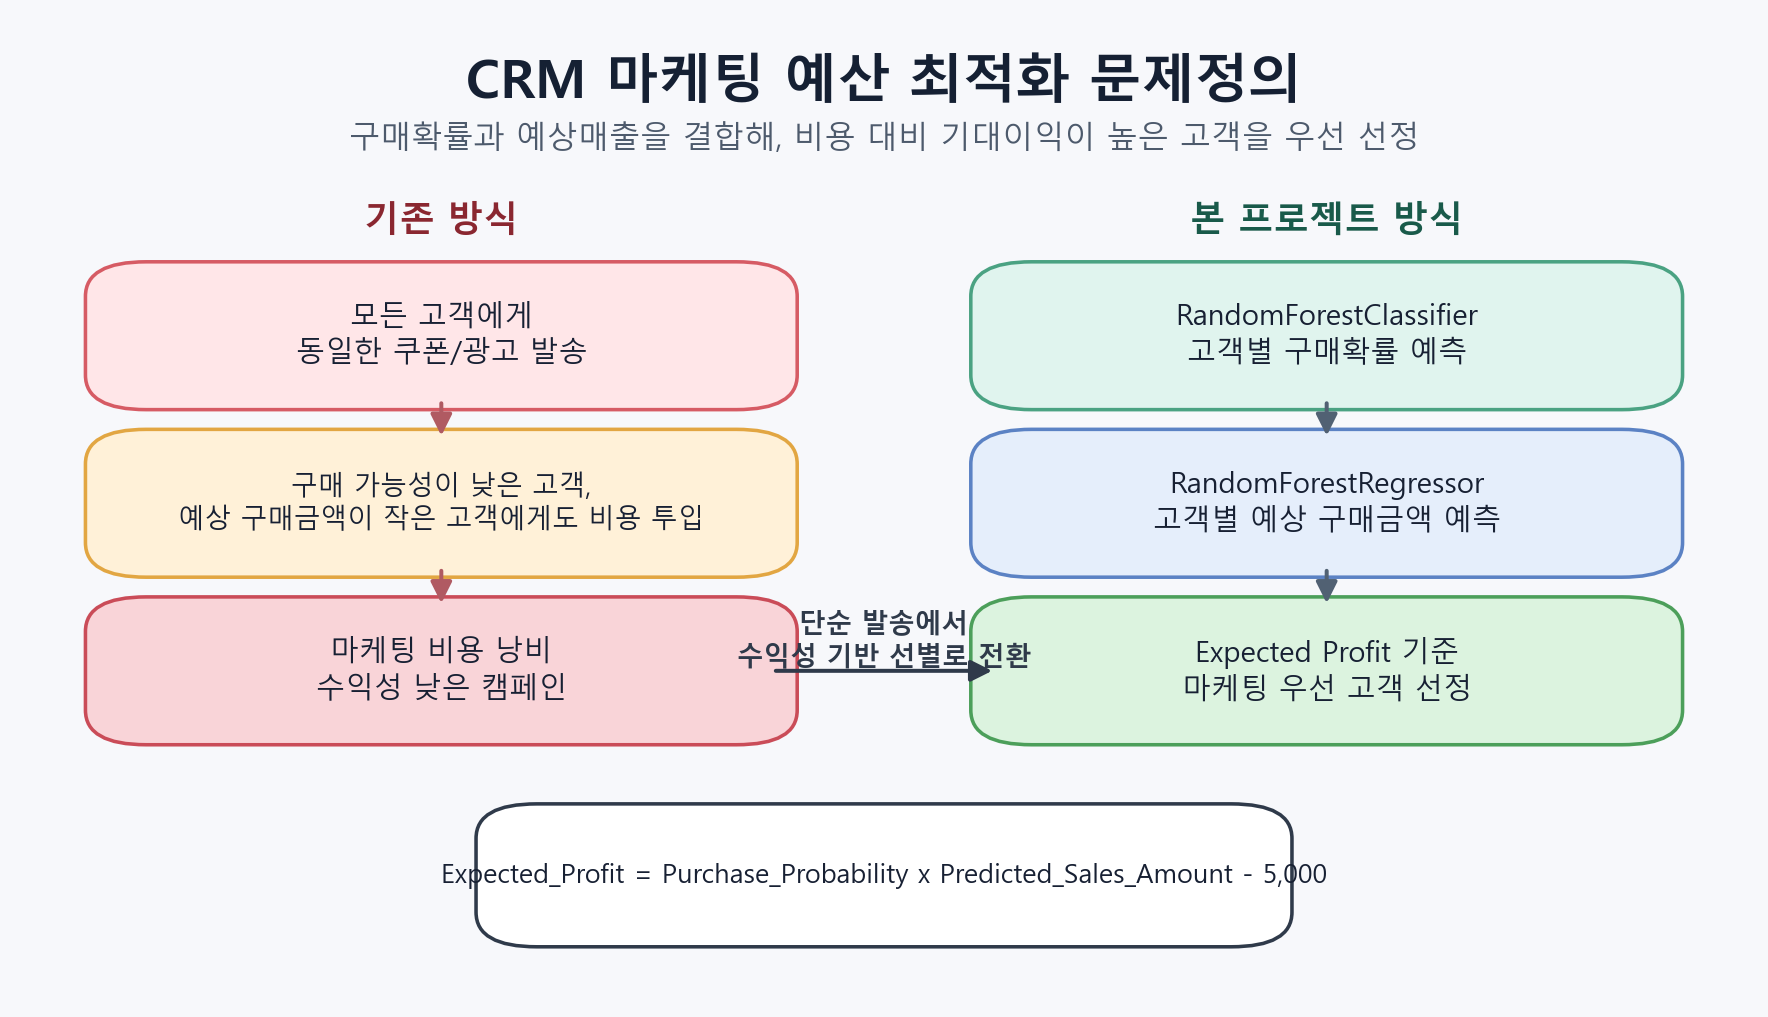

In [3]:
#@title 1. 문제정의 흐름도 보기
show_image('problem_definition_flow.png', width=1100)

# 구매 확률과 예측 매출액을 곱해 기대 매출을 계산한 뒤, 고정 마케팅 비용 5,000원을 차감해 예상 이익을 산출예상이익을 구하는 식으로 
# 예상 이익 = 구매 확률 기반 기대 매출 - 고정 마케팅 비용

# 2. 데이터 구조 및 전처리

## 여러 Excel 시트를 고객 단위 분석 데이터로 병합

Sales, Customer, Product, Date, Territory 데이터를 공통 키로 연결했습니다.  
최종적으로 고객별 RFM 지표와 선호 카테고리, 주요 구매 지역을 만들 수 있는 분석 데이터셋을 구성했습니다.

In [3]:
#@title 2. 병합 데이터 미리보기
merged = show_csv_head(DATA_DIR / 'merged_sales.csv', n=5)

파일: ..\data\processed\merged_sales.csv
크기: 121,253 rows x 39 columns


,SalesOrderLineKey,ResellerKey,CustomerKey,ProductKey,OrderDateKey,DueDateKey,ShipDateKey,SalesTerritoryKey,Order Quantity,Unit Price,...,DateKey,Date,Fiscal Year,Fiscal Quarter,Month,Full Date,MonthKey,Region,Country,Group
0,43659001,676,-1,349,20170702,20170712,20170709.0,5,1,2024.994,...,20170702,2017-07-02,FY2018,FY2018 Q1,2017 Jul,"2017 Jul, 02",201707,Southeast,United States,North America
1,43659002,676,-1,350,20170702,20170712,20170709.0,5,3,2024.994,...,20170702,2017-07-02,FY2018,FY2018 Q1,2017 Jul,"2017 Jul, 02",201707,Southeast,United States,North America
2,43659003,676,-1,351,20170702,20170712,20170709.0,5,1,2024.994,...,20170702,2017-07-02,FY2018,FY2018 Q1,2017 Jul,"2017 Jul, 02",201707,Southeast,United States,North America
3,43659004,676,-1,344,20170702,20170712,20170709.0,5,1,2039.994,...,20170702,2017-07-02,FY2018,FY2018 Q1,2017 Jul,"2017 Jul, 02",201707,Southeast,United States,North America
4,43659005,676,-1,345,20170702,20170712,20170709.0,5,1,2039.994,...,20170702,2017-07-02,FY2018,FY2018 Q1,2017 Jul,"2017 Jul, 02",201707,Southeast,United States,North America


# 고객 정보와 판매 데이터를 공통 키 기준으로 병합해 생성한 merged_sales.csv의 앞 5행을 확인
merged = show_csv_head(DATA_DIR / 'merged_sales.csv', n=5)
# 고객별 구매 이력, 매출 정보 등 분석에 필요한 데이터를 하나의 테이블로 병합한 결과를 미리보기
merged = show_csv_head(DATA_DIR / 'merged_sales.csv', n=5)
# customer_id를 기준으로 고객 데이터와 판매 데이터를 병합한 결과 파일의 앞 5행을 확인
merged = show_csv_head(DATA_DIR / 'merged_sales.csv', n=5)

In [4]:
#@title 2-1. 데이터 전처리: 결측치, 이상치, 중복 데이터 제거

# 병합된 전체 데이터를 복사하여 전처리용 데이터프레임 생성
processed = merged.copy()

# 전처리 전 데이터 크기 저장
before_rows, before_cols = processed.shape

# 1) 중복 데이터 제거: 동일한 행이 반복되어 분석 결과가 왜곡되지 않도록 제거
before_duplicates = len(processed)
processed = processed.drop_duplicates()
removed_duplicates = before_duplicates - len(processed)

# 2) 결측치 제거: 필수 정보가 비어 있는 행은 모델 학습 및 분석 안정성을 위해 제거
before_missing = len(processed)
processed = processed.dropna()
removed_missing = before_missing - len(processed)

# 3) 이상치 제거: 수치형 변수 중 ID/날짜성 컬럼을 제외하고 IQR 기준으로 과도한 값을 제거
exclude_keywords = ('key', 'id', 'date', 'year', 'month')
numeric_cols = [
    col for col in processed.select_dtypes(include='number').columns
    if not any(keyword in col.lower() for keyword in exclude_keywords)
]

before_outliers = len(processed)
for col in numeric_cols:
    Q1 = processed[col].quantile(0.25)
    Q3 = processed[col].quantile(0.75)
    IQR = Q3 - Q1

    # 값의 분포가 거의 없는 컬럼은 이상치 기준을 적용하지 않음
    if IQR == 0:
        continue

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    processed = processed[
        (processed[col] >= lower_bound) &
        (processed[col] <= upper_bound)
    ]

removed_outliers = before_outliers - len(processed)

# 전처리 결과 요약
print(f'전처리 전 데이터 크기: {before_rows:,} rows x {before_cols:,} columns')
print(f'중복 제거 행 수: {removed_duplicates:,}')
print(f'결측치 제거 행 수: {removed_missing:,}')
print(f'이상치 제거 행 수: {removed_outliers:,}')
print(f'전처리 후 데이터 크기: {processed.shape[0]:,} rows x {processed.shape[1]:,} columns')

# 이후 분석에서 사용할 수 있도록 전처리 완료 데이터 저장
processed.to_csv(DATA_DIR / 'merged_sales_preprocessed.csv', index=False, encoding='utf-8-sig')

processed.head()


전처리 전 데이터 크기: 121,253 rows x 39 columns
중복 제거 행 수: 0
결측치 제거 행 수: 35,434
이상치 제거 행 수: 24,503
전처리 후 데이터 크기: 61,316 rows x 39 columns


,SalesOrderLineKey,ResellerKey,CustomerKey,ProductKey,OrderDateKey,DueDateKey,ShipDateKey,SalesTerritoryKey,Order Quantity,Unit Price,...,DateKey,Date,Fiscal Year,Fiscal Quarter,Month,Full Date,MonthKey,Region,Country,Group
7,43659008,676,-1,229,20170702,20170712,20170709.0,5,3,28.8404,...,20170702,2017-07-02,FY2018,FY2018 Q1,2017 Jul,"2017 Jul, 02",201707,Southeast,United States,North America
8,43659009,676,-1,235,20170702,20170712,20170709.0,5,1,28.8404,...,20170702,2017-07-02,FY2018,FY2018 Q1,2017 Jul,"2017 Jul, 02",201707,Southeast,United States,North America
9,43659010,676,-1,218,20170702,20170712,20170709.0,5,6,5.7000,...,20170702,2017-07-02,FY2018,FY2018 Q1,2017 Jul,"2017 Jul, 02",201707,Southeast,United States,North America
10,43659011,676,-1,223,20170702,20170712,20170709.0,5,2,5.1865,...,20170702,2017-07-02,FY2018,FY2018 Q1,2017 Jul,"2017 Jul, 02",201707,Southeast,United States,North America
11,43659012,676,-1,220,20170702,20170712,20170709.0,5,4,20.1865,...,20170702,2017-07-02,FY2018,FY2018 Q1,2017 Jul,"2017 Jul, 02",201707,Southeast,United States,North America


CustomerKey는 고객 단위 분석 기준이고, Sales Amount는 매출과 Monetary 계산의 핵심 컬럼입니다. Date는 월별 매출 추세와 Recency 계산에 사용되고, Category는 상품 카테고리별 매출 및 고객 선호 카테고리 분석에 사용됩니다. Region, Country, Group은 지역별 매출 분석과 고객의 주요 구매 지역 feature 생성에 활용됩니다.

# 3. 월별 매출 추세 EDA

## 매출이 시간에 따라 어떻게 변화하는지 확인

월별 매출 추세는 CRM 예산을 어느 시점에 집중할지 판단하는 배경 자료입니다.  
단순히 매출이 높은 시기를 찾는 것이 아니라, 비용 대비 효과가 큰 시점을 함께 고려해야 합니다.

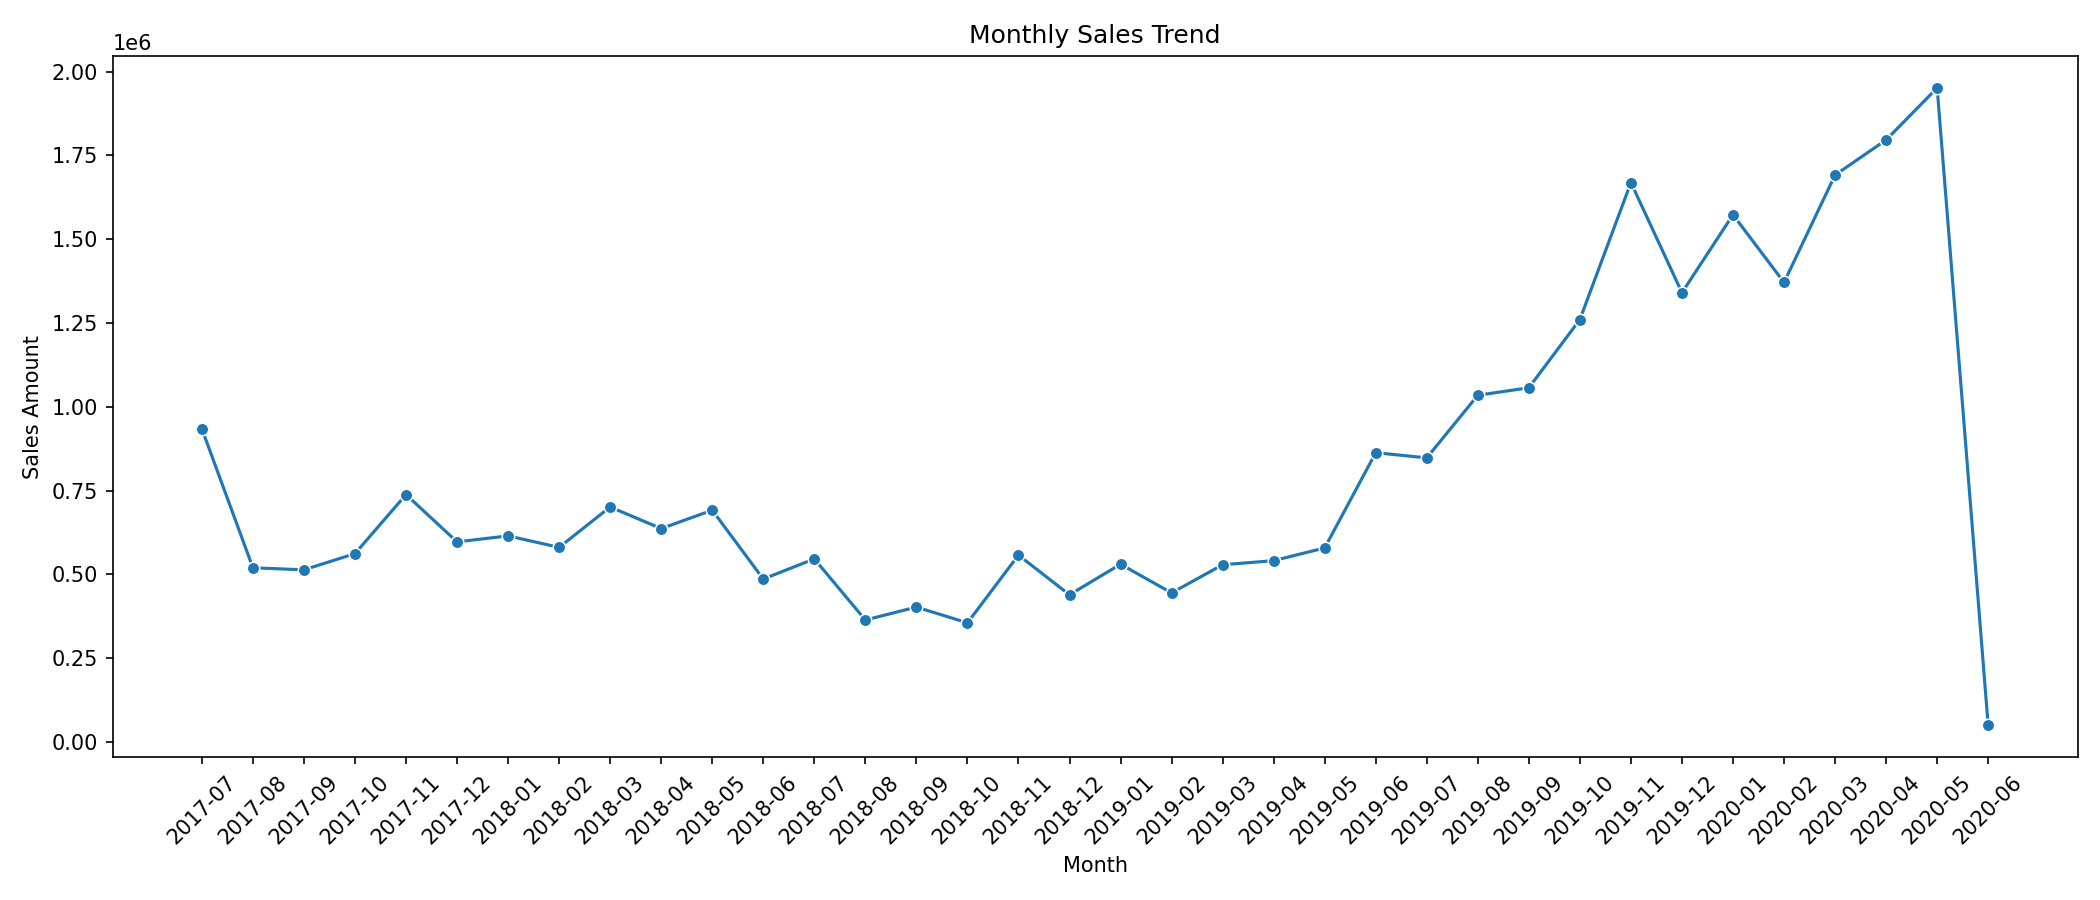

In [5]:
#@title 3. 월별 매출 추세 그래프
show_image('monthly_sales_trend.png', width=1000)

# 월별 매출 흐름을 확인해 성수기·비수기와 마케팅 집중 시점을 파악

# 4. 지역별 매출 분석

## 지역마다 다른 매출 규모와 고객 특성 확인

지역 정보는 구매확률과 예상매출을 설명하는 feature로 활용됩니다.  
하지만 최종 마케팅 대상은 지역 매출 순위가 아니라 고객별 Expected Profit 기준으로 선정합니다.

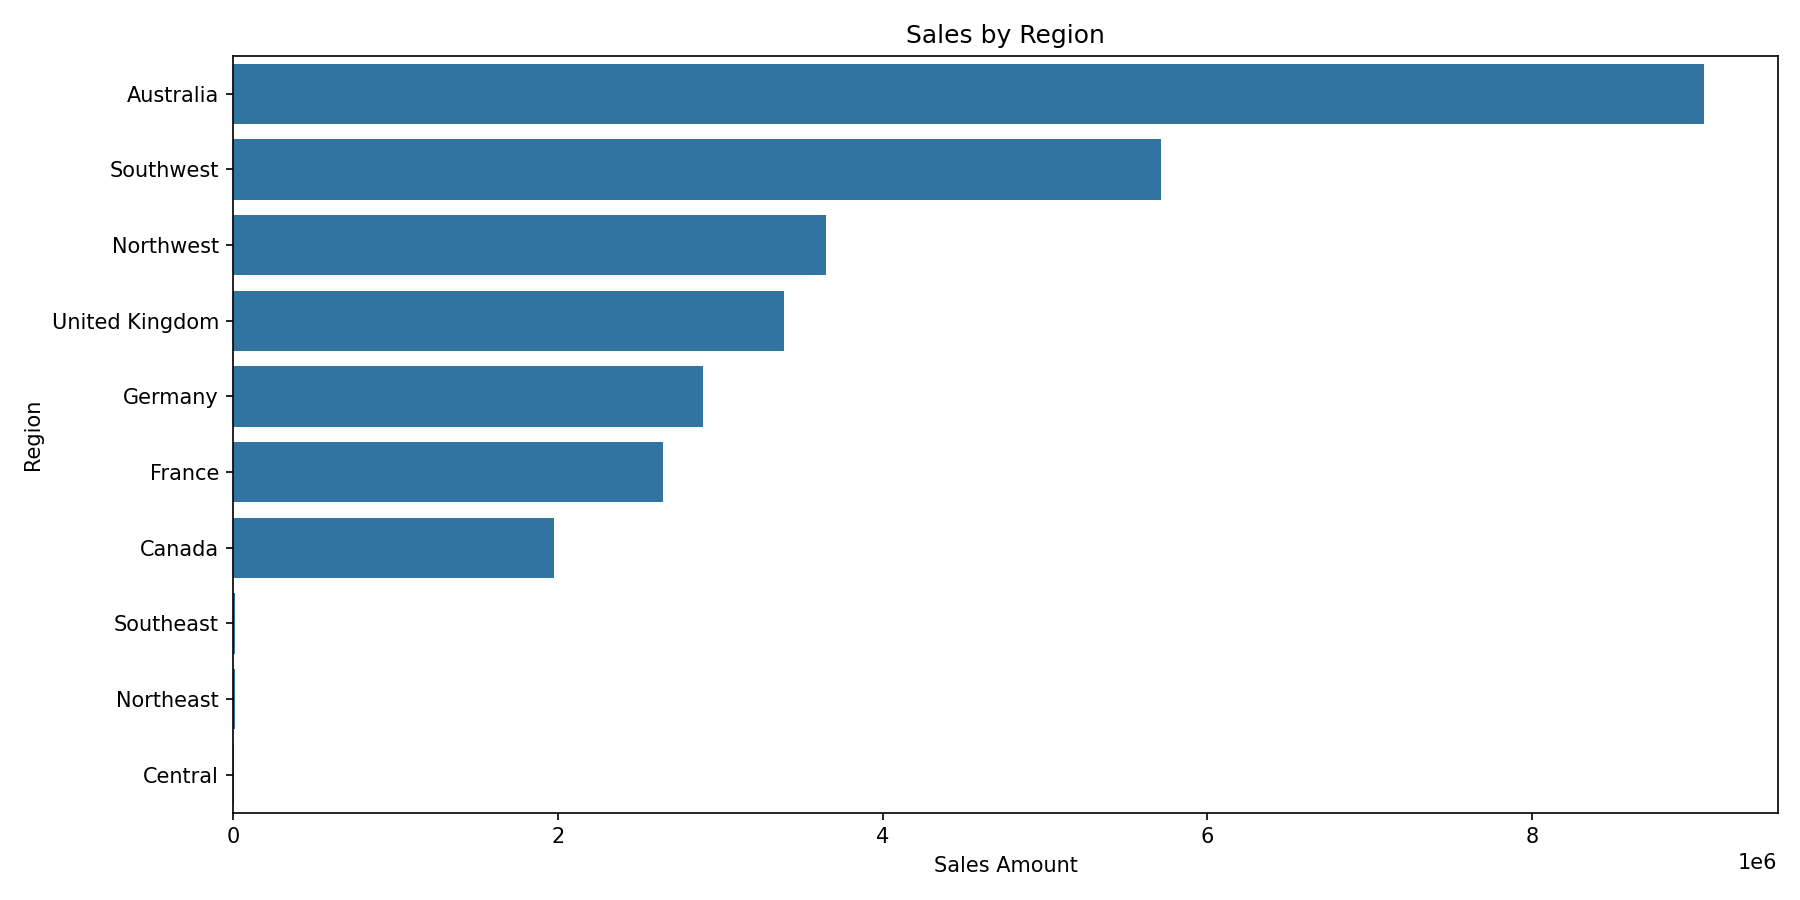

In [6]:
#@title 4. 지역별 매출 그래프
show_image('sales_by_region.png', width=900)

지역별 매출 차이를 확인해서 핵심 지역과 개선이 필요한 지역을 구분할 수 있습니다.

# 5. 상품 카테고리별 매출 분석

## 어떤 상품군이 매출에 크게 기여하는지 확인

상품 카테고리 분석은 고객별 선호 상품과 CRM 메시지 방향을 정하는 데 도움이 됩니다.  
다만 예산 배분 기준은 선호 카테고리가 아니라 Expected Profit입니다.

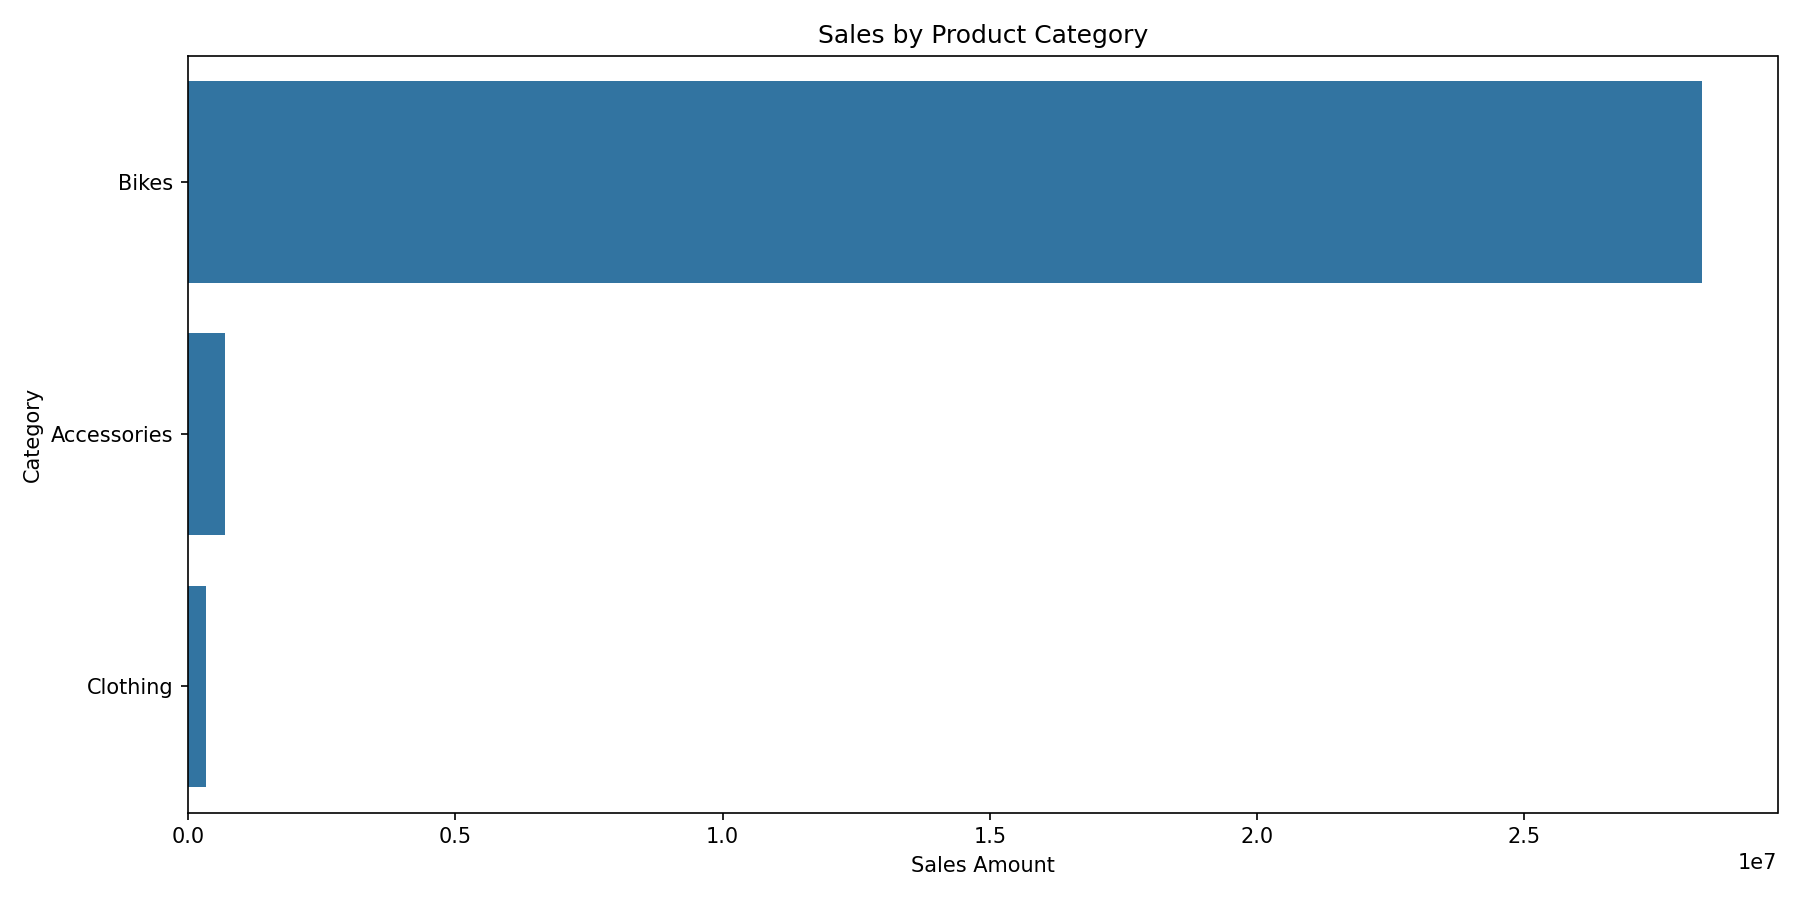

In [7]:
#@title 5. 상품 카테고리별 매출 그래프
show_image('sales_by_category.png', width=900)

이 그래프를 통해 어떤 상품 카테고리가 전체 매출에 가장 크게 기여하는지 확인할 수 있습니다. 매출이 높은 카테고리는 핵심 상품군으로 보고 마케팅을 유지하거나 확대할 수 있고, 매출이 낮은 카테고리는 프로모션이나 상품 전략 개선이 필요한 대상으로 해석할 수 있습니다.

# 6. 고객별 구매금액 분석

## 고객별 매출 기여도가 크게 다르다는 점 확인

고객마다 구매금액 차이가 크기 때문에 동일한 마케팅 비용을 투입해도 결과는 달라집니다.  
이 차이를 반영하기 위해 고객별 예상 구매금액을 회귀 모델로 예측합니다.

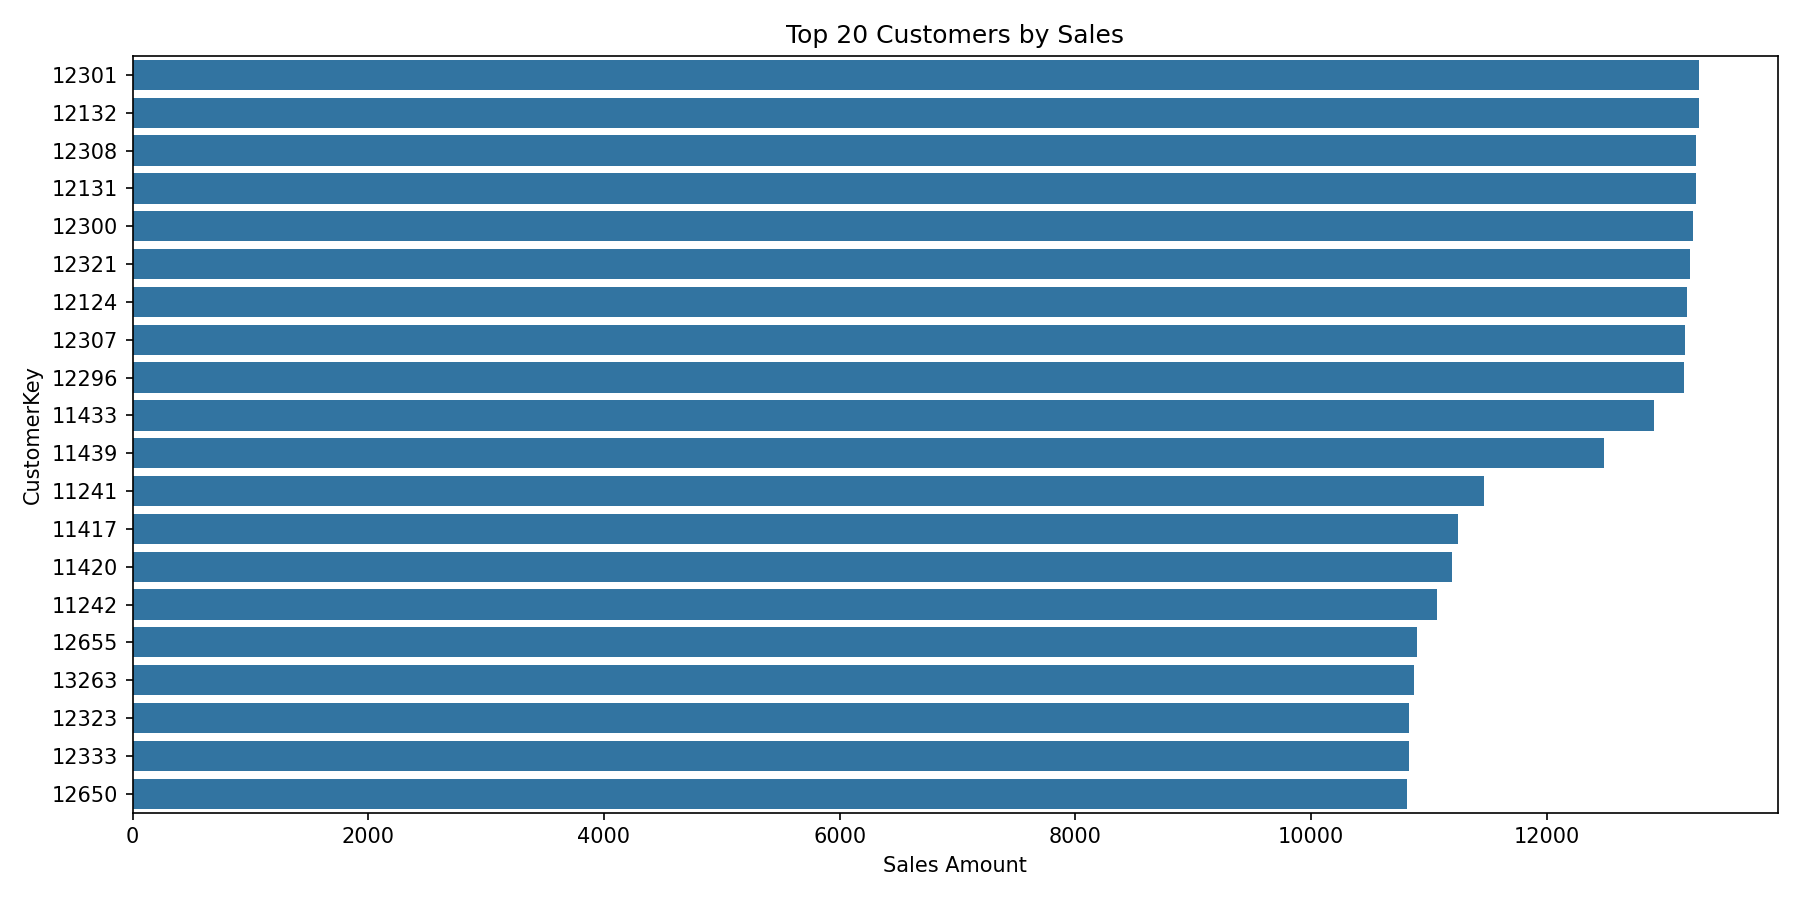

In [8]:
#@title 6. 상위 구매 고객 그래프
show_image('top_20_customers.png', width=900)

# 7. RFM 분석

## Recency, Frequency, Monetary로 고객 구매 행동 요약

RFM은 고객의 최근성, 구매 빈도, 구매금액을 요약하는 핵심 지표입니다.  
최신 산출물은 `CustomerKey <= 0`인 비고객 행을 제거한 뒤 다시 생성했습니다.

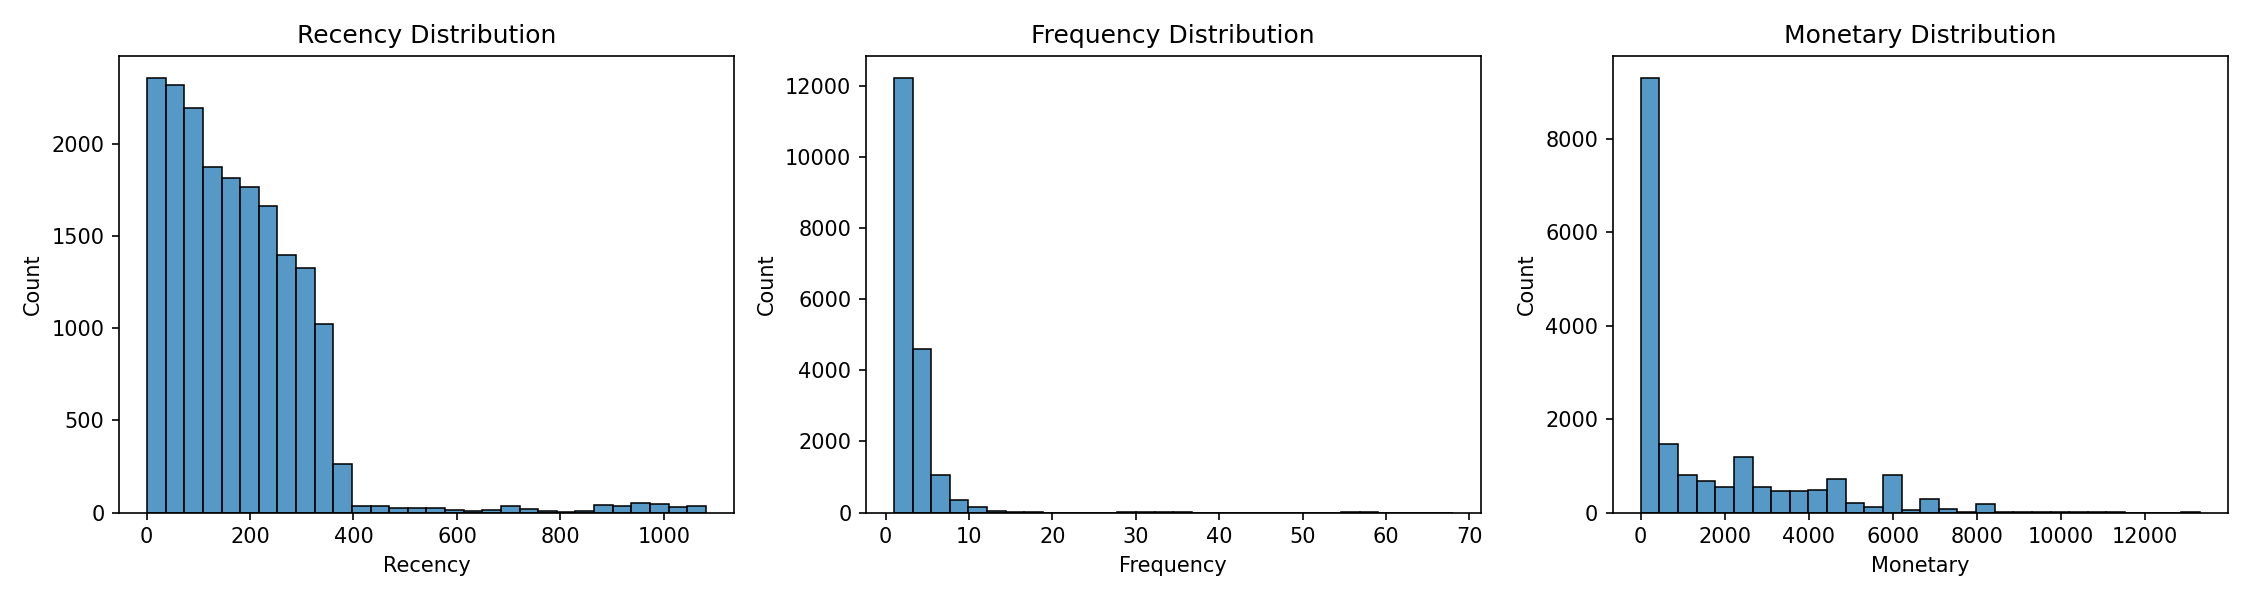

In [9]:
#@title 7-1. RFM 분포 그래프
show_image('rfm_distributions.png', width=1100)

RFM 분석을 통해 고객을 구매 행동 기준으로 세분화하고, 마케팅 우선순위가 높은 고객군을 식별할 수 있습니다. 이를 통해 CRM 마케팅에서 누구에게 예산을 집중해야 하는지 판단할 수 있습니다.

In [10]:
#@title 7-2. RFM 데이터 검증
rfm = show_csv_head(REPORTS_DIR / 'rfm_customer_features.csv', n=10)
if rfm is not None:
    print('CustomerKey <= 0 rows:', int((rfm['CustomerKey'] <= 0).sum()))
    print('Max Monetary:', round(rfm['Monetary'].max(), 2))

파일: ..\outputs\reports\rfm_customer_features.csv
크기: 18,484 rows x 4 columns


,CustomerKey,Recency,Frequency,Monetary
0,12301,55,13,13295.3800
1,12132,89,14,13294.2700
2,12308,56,14,13269.2700
3,12131,96,11,13265.9900
4,12300,89,10,13242.7000
5,12321,54,15,13215.6500
6,12124,99,12,13195.6400
7,12307,58,11,13173.1900
8,12296,81,12,13164.6400
9,11433,122,12,12909.6682


CustomerKey <= 0 rows: 0
Max Monetary: 13295.38


이 단계에서는 생성된 RFM 데이터가 고객 단위 분석에 적합한지 검증했습니다. CustomerKey가 0 이하인 잘못된 고객 ID가 있는지 확인하고, Monetary의 최댓값을 확인하여 구매금액 값이 비정상적으로 생성되지 않았는지 점검했습니다. 이를 통해 이후 고객 세분화와 마케팅 타겟 선정에 사용할 RFM 데이터의 기본 품질을 확인할 수 있습니다.

# 8. Classification 결과

## RandomForestClassifier로 고객별 구매확률 예측

분류 모델은 고객별 구매 가능성을 예측합니다.  
이 값은 최종 Expected Profit 공식에서 `Purchase_Probability`로 사용됩니다.

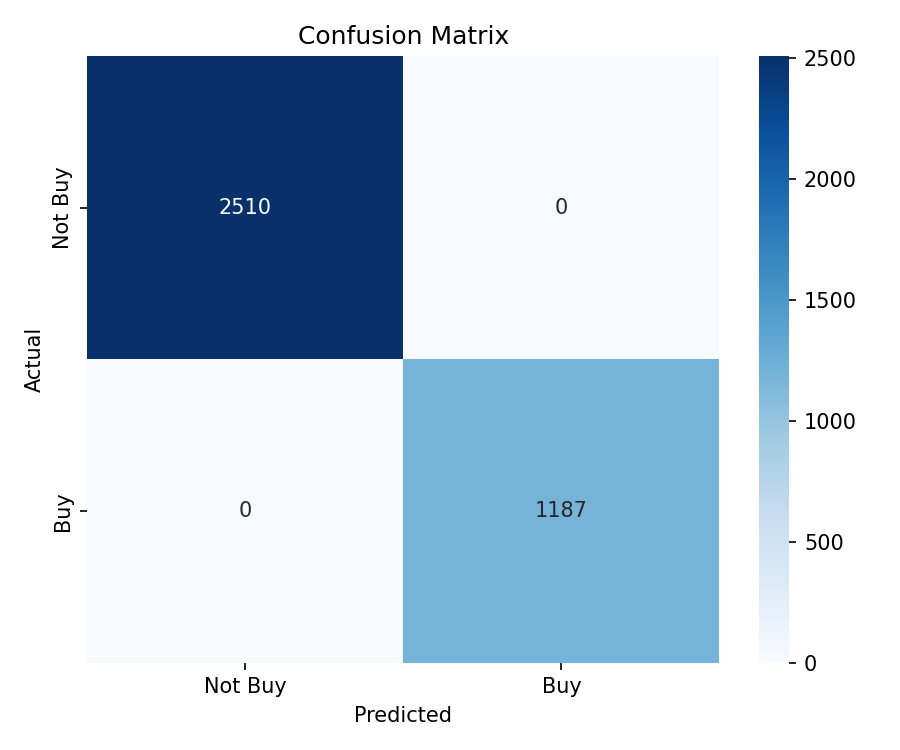

In [11]:
#@title 8-1. Confusion Matrix
show_image('confusion_matrix.png', width=700)

# Confusion Matrix를 통해 실제 구매 여부와 모델의 예측 결과를 비교하여
# 구매 고객/비구매 고객을 얼마나 정확히 분류했는지 확인
Confusion Matrix는 모델의 예측 결과가 실제값과 얼마나 일치하는지 보여주는 표입니다. 이를 통해 모델이 실제 구매 고객을 구매 고객으로 잘 예측했는지, 또는 비구매 고객을 잘못 구매 고객으로 예측했는지 확인할 수 있습니다. CRM 마케팅에서는 특히 구매 가능성이 높은 고객을 놓치지 않는 것이 중요하기 때문에, 실제 구매 고객을 얼마나 잘 찾아냈는지를 확인하는 데 활용됩니다.

In [12]:
#@title 8-2. Classification Report
show_text_file(REPORTS_DIR / 'classifier_report.txt')

RandomForestClassifier Evaluation Report
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Confusion Matrix
[[2510    0]
 [   0 1187]]

CRM Marketing Budget Optimization
Expected_Profit = Purchase_Probability * Predicted_Sales_Amount - Marketing_Cost
Marketing_Cost: 5,000
Marketing target count(top 20% by Expected_Profit): 3,696
Average Expected_Profit among targets: -1,657.51
Minimum Expected_Profit among targets: -4,809.18
Maximum Expected_Profit among targets: 8,181.27

Top 15 Feature Importance
                      feature  importance
                      Recency    0.581970
               total_quantity    0.193384
                    Frequency    0.160556
                     Monetary    0.032668
             avg_order_amount    0.022721
        main_region_Australia    0.002154
favorite_category_Accessories    0.001674
   favorite_category_Clothing    0.001189
      favorite_category_Bikes    0.000953
           main_region_Canada    0.000643
        main_reg

RandomForestClassifier 모델은 테스트 데이터에서 Accuracy, Precision, Recall, F1-score가 모두 1.0으로 나타났습니다. 즉, 현재 평가 데이터 기준으로는 구매 고객과 비구매 고객을 모두 정확히 분류했습니다.

[[2510    0]
 [   0 1187]] 실제 비구매고객 2510명 실제 구매고객 1187명으로 모두 잘 예측함 

 Feature Importance를 보면 구매 여부 예측에 가장 큰 영향을 준 변수는 Recency였습니다. 즉, 고객이 얼마나 최근에 구매했는지가 구매 가능성을 판단하는 데 가장 중요한 요소로 작용했습니다. 그 다음으로는 총 구매 수량과 구매 빈도가 중요한 변수로 나타났습니다.

 마케팅 대상은 단순히 구매확률이 높은 고객이 아니라, 구매확률과 예상 매출액을 함께 고려한 Expected Profit 기준으로 선정했습니다. 이를 통해 구매 가능성은 높지만 예상 수익이 낮은 고객보다, 실제 기대 이익이 높은 고객을 우선적으로 타겟팅할 수 있습니다.

 상위 20% 고객을 선정했음에도 평균 Expected Profit이 음수로 나타났습니다. 이는 고객당 마케팅 비용 5,000원이 예상 수익보다 큰 경우가 많다는 의미입니다. 따라서 모든 상위 20% 고객에게 마케팅하기보다는 Expected Profit이 0보다 큰 고객만 선별하는 방식이 더 효율적일 수 있습니다.

# 9. Classification Feature Importance

## 구매 가능성 판단에 중요한 변수 확인

Recency, Frequency, total_quantity 같은 고객 행동 지표가 구매 가능성 예측에 중요한 역할을 합니다.  
다만 Buy 라벨이 RFM 기준으로 생성되었기 때문에 성능과 중요도는 조심해서 해석해야 합니다.

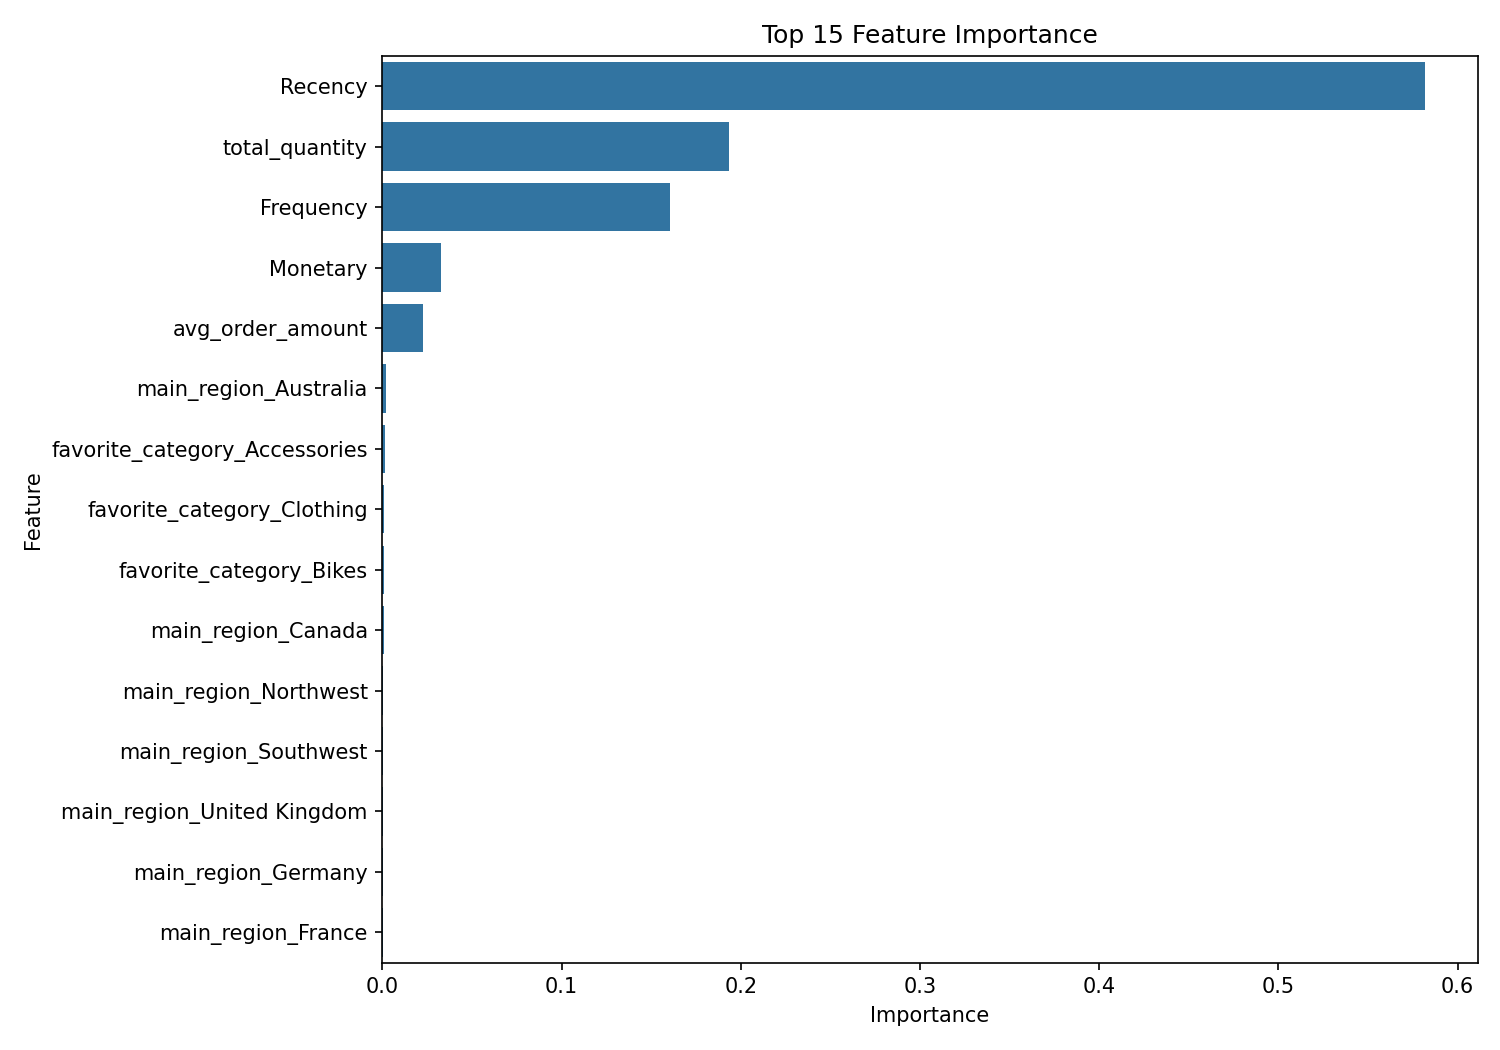

In [13]:
#@title 9. Classification Feature Importance
show_image('classifier_feature_importance.png', width=900)

Classification Feature Importance를 통해 구매 여부 예측에 가장 영향을 많이 준 변수를 확인했습니다. 이를 통해 모델이 어떤 고객 특성을 근거로 구매 가능성을 판단했는지 해석할 수 있고, CRM 마케팅에서는 해당 변수를 중심으로 타겟 고객을 선정할 수 있습니다.
누가 살 가능성이 높은가?

# 10. Regression 결과

## RandomForestRegressor로 고객별 예상 구매금액 예측

회귀 모델은 고객이 구매할 경우 어느 정도의 매출을 만들 수 있는지 예측합니다.  
이 값은 Expected Profit 공식에서 `Predicted_Sales_Amount`로 사용됩니다.

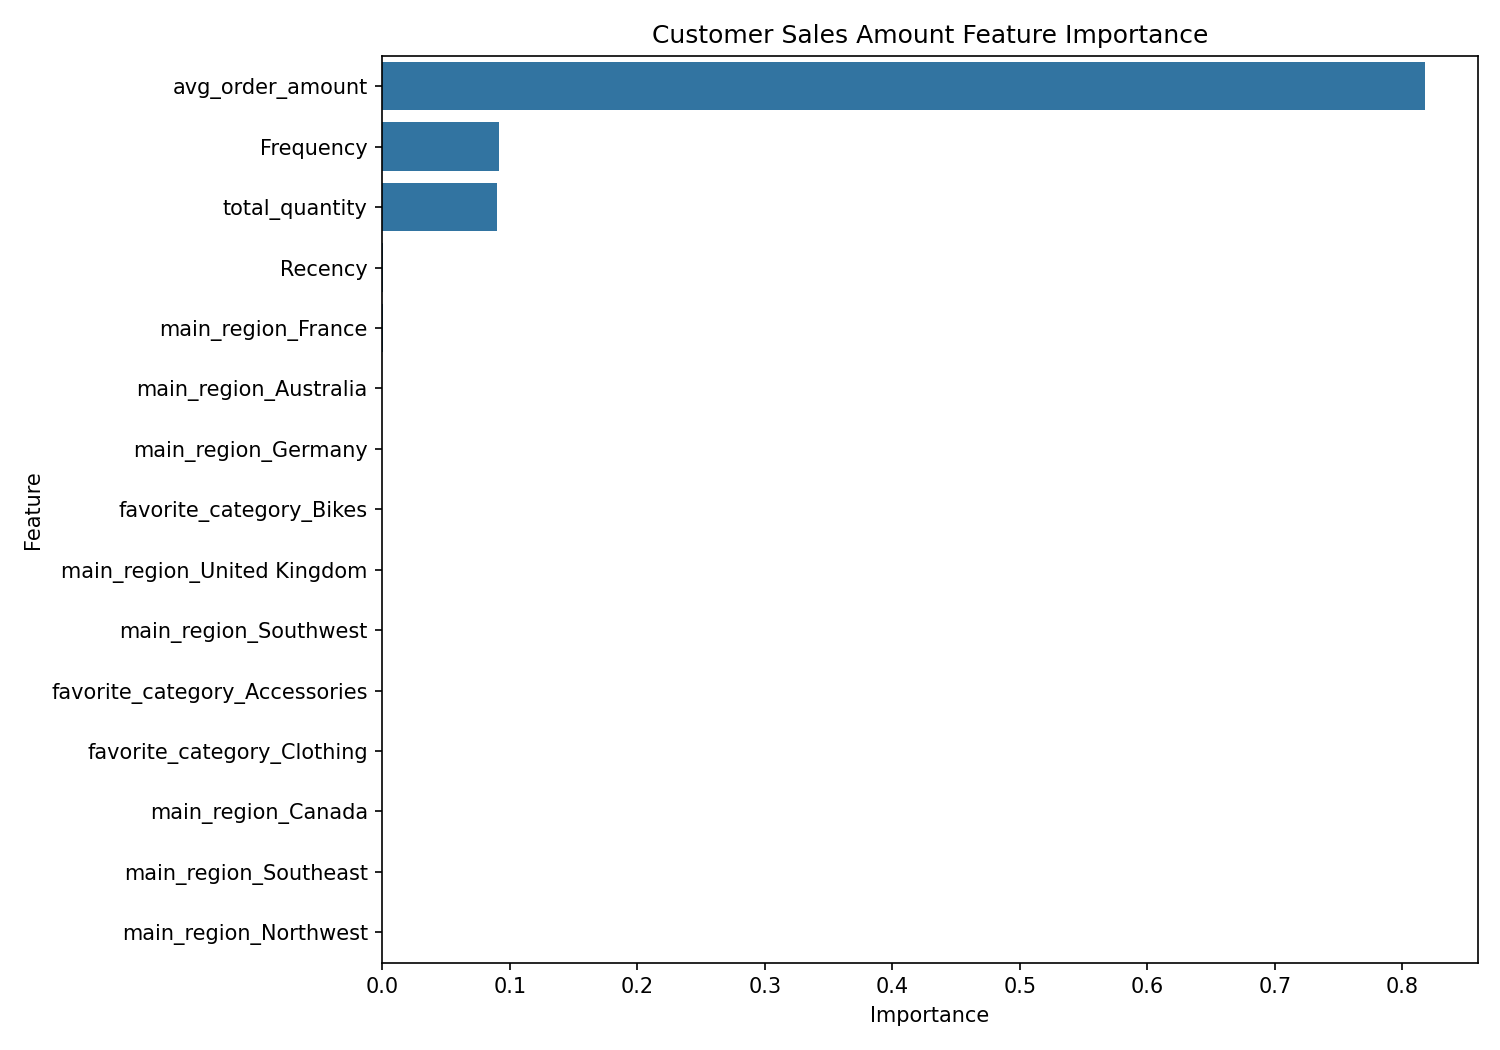

In [14]:
#@title 10-1. Regression Feature Importance
show_image('regressor_feature_importance.png', width=900)

이 그래프는 회귀 모델이 고객의 예상 매출액을 예측할 때 어떤 변수를 중요하게 사용했는지 보여줍니다. 중요도가 높은 변수(고객의 평균 주문 금액)는 예상 구매금액이나 매출 규모를 판단하는 데 큰 영향을 준 변수입니다. 이를 통해 단순히 구매할 가능성이 높은 고객뿐만 아니라, 실제로 구매했을 때 더 큰 매출을 만들 가능성이 높은 고객의 특징을 파악할 수 있습니다. 즉, 구매확률이 아닌 구매 시 예상 매출 규모를 설명하는 핵심 요인임  
즉, 예상매출을 예측할때 어떤 변수가 가장 중요한지 


9번에서는 고객이 구매할 가능성이 있는지를 분류 모델로 예측했고, 10번에서는 구매했을 때 얼마만큼의 매출을 만들 수 있는지를 회귀 모델로 예측했습니다. 이후 두 결과를 결합해 기대이익 기반으로 마케팅 대상을 선정했습니다.

In [15]:
#@title 10-2. Regression Report
show_text_file(REPORTS_DIR / 'regressor_report.txt')

RandomForestRegressor Evaluation Report
Goal: Predict customer-level expected purchase amount
Target column: Monetary

MAE: 6.2597
RMSE: 65.7180
R2: 0.9991

Top 15 Feature Importance
                      feature   importance
             avg_order_amount 8.180307e-01
                    Frequency 9.119423e-02
               total_quantity 8.978147e-02
                      Recency 5.142416e-04
           main_region_France 2.562834e-04
        main_region_Australia 6.579036e-05
          main_region_Germany 5.817950e-05
      favorite_category_Bikes 5.568014e-05
   main_region_United Kingdom 2.433618e-05
        main_region_Southwest 7.834417e-06
favorite_category_Accessories 4.163249e-06
   favorite_category_Clothing 3.186053e-06
           main_region_Canada 2.124866e-06
        main_region_Southeast 9.455749e-07
        main_region_Northwest 8.150906e-07


RandomForestRegressor 모델은 고객별 예상 구매금액인 Monetary를 예측하기 위해 사용되었습니다. 평가 결과 R2 값이 0.9991로 매우 높게 나타나, 모델이 실제 고객별 구매금액을 거의 잘 설명하고 있음을 확인할 수 있습니다. MAE는 약 6.26, RMSE는 약 65.72로 나타났으며, 이는 예측값과 실제값의 평균적인 차이가 크지 않다는 의미입니다.

#MAE는 실제값과 예측값의 차이를 절댓값으로 평균낸 값입니다.

모델이 고객별 구매금액을 예측할 때 평균적으로 약 6.26 정도 차이가 난다는 의미입니다.

MAE는 값이 작을수록 좋습니다.

#RMSE는 큰 오차에 더 민감한 평가 지표입니다.
예측이 크게 틀린 경우가 있으면 RMSE가 더 크게 올라갑니다.


#R2는 모델이 실제 데이터의 변동을 얼마나 잘 설명하는지를 나타냅니다.

값은 보통 0에서 1 사이이고, 1에 가까울수록 좋습니다. 즉, 매우 높은 설명력을 가진 모델이라고 볼 수 있습니다.


# 11. Expected Profit 결과

## 구매확률과 예상매출을 결합해 최종 마케팅 우선순위 계산

이 프로젝트의 핵심은 구매확률 TOP 고객 선정이 아닙니다.  
구매확률, 예상 구매금액, 마케팅 비용을 모두 반영한 Expected Profit 기준으로 고객을 선정합니다.

In [16]:
#@title 11. Expected Profit 상위 고객
targets = show_csv_head(REPORTS_DIR / 'marketing_targets_expected_profit.csv', n=15)
if targets is not None:
    print('Marketing target rows:', len(targets))
    print('Expected_Profit max:', round(targets['Expected_Profit'].max(), 2))
    print('Expected_Profit mean:', round(targets['Expected_Profit'].mean(), 2))
    print('Expected_Profit > 0 rows:', int((targets['Expected_Profit'] > 0).sum()))

파일: ..\outputs\reports\marketing_targets_expected_profit.csv
크기: 3,696 rows x 6 columns


,CustomerKey,Buy_Label,Purchase_Probability,Predicted_Sales_Amount,Marketing_Cost,Expected_Profit
0,12296,1,1.00,13181.272182,5000,8181.272182
1,12124,1,1.00,13175.157982,5000,8175.157982
2,12131,1,1.00,13002.259525,5000,8002.259525
3,12301,1,0.99,13035.190364,5000,7904.838460
4,12307,1,1.00,12870.856200,5000,7870.856200
5,12308,1,1.00,12671.179509,5000,7671.179509
6,12132,1,1.00,12559.018153,5000,7559.018153
7,11433,1,0.96,12870.954383,5000,7356.116208
8,12300,1,0.99,12019.501850,5000,6899.306831
9,12321,1,1.00,10924.384157,5000,5924.384157


Marketing target rows: 3696
Expected_Profit max: 8181.27
Expected_Profit mean: -1657.51
Expected_Profit > 0 rows: 846


## 11-2. 구매확률 TOP 20% vs Expected Profit TOP 20%

## 이 프로젝트의 결론을 가장 직접적으로 보여주는 비교

구매확률이 높은 고객을 고르는 전략과 Expected Profit이 높은 고객을 고르는 전략을 비교합니다.  
Expected Profit 기준은 구매확률뿐 아니라 예상 구매금액과 마케팅 비용까지 반영하기 때문에 CRM 예산 최적화 관점에 더 적합합니다.

### 분석 이미지 해석 주석

아래 비교 그래프는 `구매확률 TOP 20%`와 `Expected Profit TOP 20%`를 나란히 비교합니다.  
Expected Profit 기준으로 고르면 평균 기대이익 손실이 더 작고, 전체 기대이익도 더 개선됩니다.  
또 기대이익이 0보다 큰 고객 수가 구매확률 기준보다 더 많습니다.  
즉 단순히 구매확률이 높은 고객보다, 구매확률과 예상매출을 함께 고려해 수익성이 확보된 고객이 더 중요한 타깃이라는 결론을 보여줍니다.

### 표 숫자 해석 주석

`Purchase Probability Top 20%`는 구매확률이 높은 고객 20%를 선택한 전략입니다.  
`Expected Profit Top 20%`는 구매확률, 예상 구매금액, 마케팅 비용을 모두 반영한 기대이익 기준으로 고객 20%를 선택한 전략입니다.  
두 전략의 대상 고객 수는 모두 3,696명으로 동일하지만 결과는 다릅니다.  
구매확률 기준 전략의 평균 Expected Profit은 약 -2,302이고, Expected Profit 기준 전략의 평균 Expected Profit은 약 -1,658입니다.  
또 Expected Profit이 0보다 큰 고객 수는 구매확률 기준이 639명, Expected Profit 기준이 846명입니다.

### 발표 대본

이 슬라이드는 이 프로젝트의 결론을 가장 직접적으로 보여주는 비교입니다.  
왼쪽 전략은 구매확률이 높은 고객 상위 20%를 고른 것이고, 오른쪽 전략은 Expected Profit이 높은 고객 상위 20%를 고른 것입니다.  
두 전략 모두 고객 수는 3,696명으로 같지만, 평균 기대이익과 양수 기대이익 고객 수에서 차이가 납니다.  
구매확률 기준으로 고르면 평균 Expected Profit이 약 -2,302로 나타났고, Expected Profit 기준으로 고르면 약 -1,658로 손실 폭이 줄어듭니다.  
또 실제로 마케팅 비용을 제외하고도 이익이 남는 고객 수는 구매확률 기준 639명에서 Expected Profit 기준 846명으로 증가합니다.  
이 결과는 구매확률이 높다고 해서 반드시 좋은 마케팅 대상은 아니라는 점을 보여줍니다.  
결국 CRM 예산을 효율적으로 쓰려면 구매확률뿐 아니라 예상매출과 마케팅 비용까지 함께 고려해야 합니다.  
다만 top 20% 전체 평균이 아직 음수이기 때문에, 실제 운영에서는 Expected Profit이 0보다 큰 고객을 우선 타깃으로 삼는 것이 더 적절합니다.

### 이 슬라이드의 결론 문장

```text
구매확률이 높은 고객보다, 구매확률과 예상매출을 결합했을 때 마케팅 비용을 회수할 수 있는 고객이 더 중요한 CRM 타깃입니다.
```

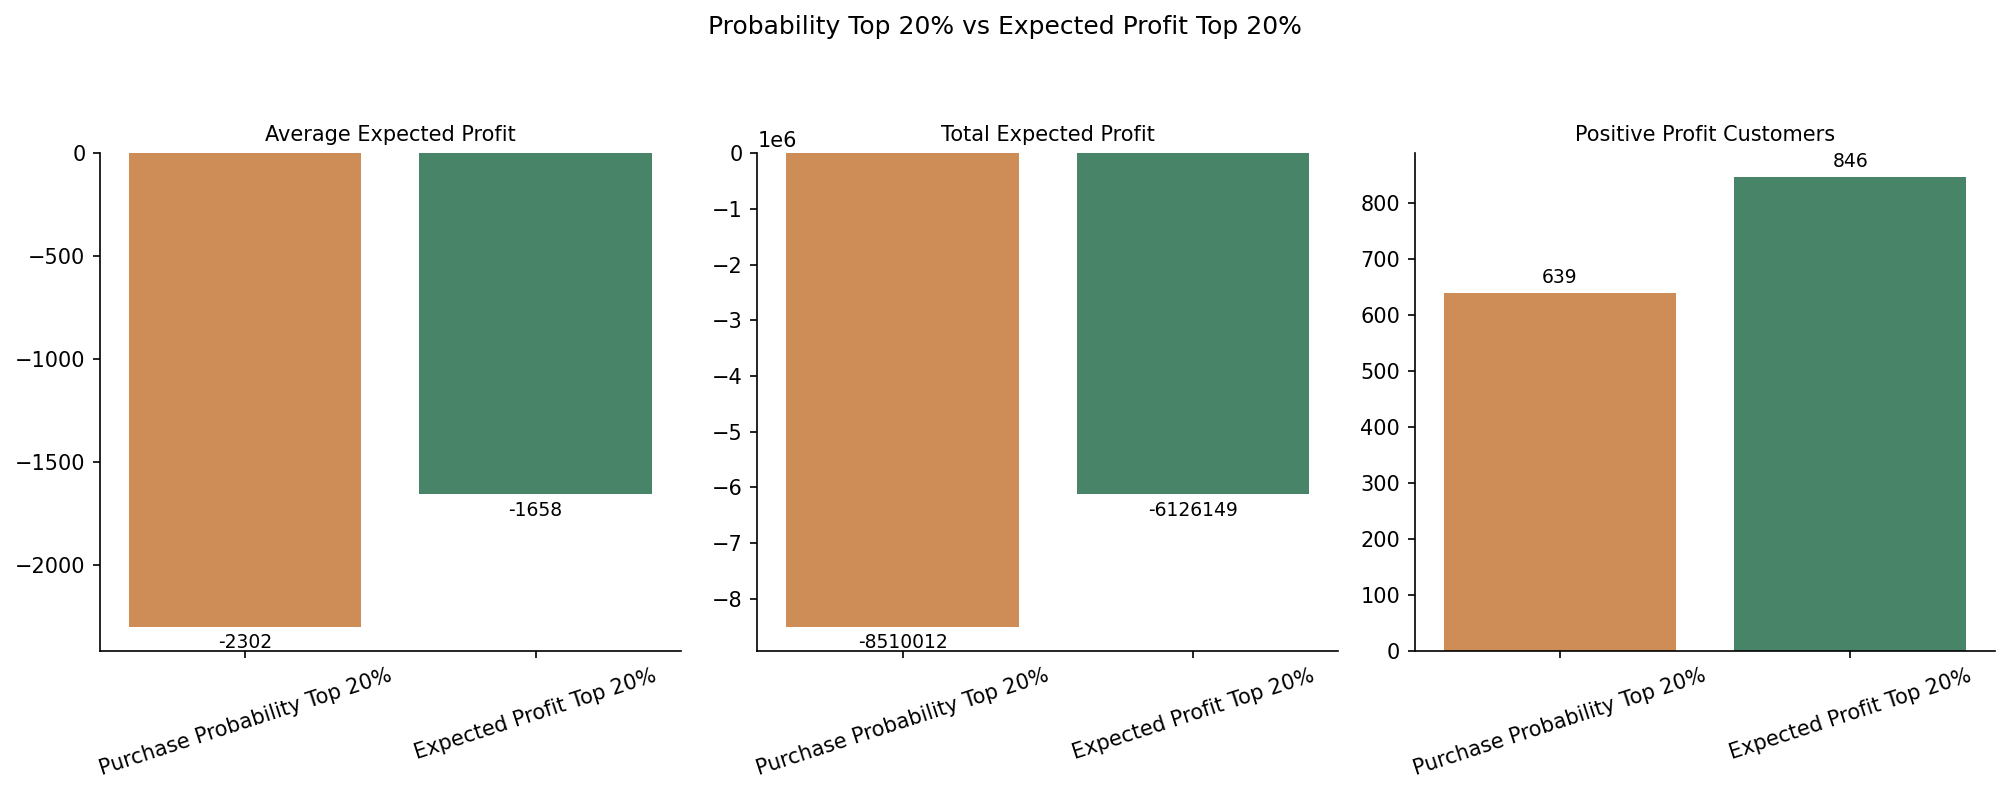

,strategy,target_count,avg_purchase_probability,avg_predicted_sales_amount,avg_expected_profit,total_expected_profit,positive_expected_profit_count,min_expected_profit,max_expected_profit,overlap_with_other_strategy
0,Purchase Probability Top 20%,3696,1.000000,2697.507632,-2302.492368,-8.510012e+06,639,-4902.5216,8181.272182,3048
1,Expected Profit Top 20%,3696,0.988536,3412.731662,-1657.507887,-6.126149e+06,846,-4809.1758,8181.272182,3048


In [4]:
#@title 11-2. 구매확률 기준과 Expected Profit 기준 비교

# 구매확률만 기준으로 선정한 고객군과 Expected Profit 기준으로 선정한 고객군의 차이를 시각적으로 비교
show_image('probability_vs_expected_profit_strategy_comparison.png', width=1100)

# 비교 요약 CSV가 존재하는지 확인한 뒤 불러오기
summary_path = REPORTS_DIR / 'probability_vs_expected_profit_summary.csv'

if summary_path.exists():
    comparison = pd.read_csv(summary_path)
    display(comparison)
else:
    display(Markdown(f'**CSV 없음:** {summary_path}'))
    print('현재 REPORTS_DIR:', REPORTS_DIR.resolve())
    print('outputs/reports 폴더가 현재 실행 위치 기준으로 올바른지 확인하세요.')


# 12. CRM Action 해석

## Expected Profit 기준으로 고객별 액션을 다르게 설계

Expected Profit이 높은 고객은 비용이 드는 쿠폰이나 프로모션 대상으로 적합합니다.  
Expected Profit이 낮거나 음수인 고객은 저비용 메시지, 관찰군, 또는 제외 대상으로 분류하는 것이 합리적입니다.

In [17]:
#@title 12. CRM Action 예시 생성
if 'targets' not in globals() or targets is None:
    targets = pd.read_csv(REPORTS_DIR / 'marketing_targets_expected_profit.csv')

action_view = targets.copy()
action_view['CRM_Action'] = pd.cut(
    action_view['Expected_Profit'],
    bins=[float('-inf'), 0, 3000, float('inf')],
    labels=['유료 예산 제외', '저비용 CRM', '우선 프로모션']
)

display(action_view[['CustomerKey', 'Purchase_Probability', 'Predicted_Sales_Amount', 'Marketing_Cost', 'Expected_Profit', 'CRM_Action']].head(15))
display(action_view['CRM_Action'].value_counts())

,CustomerKey,Purchase_Probability,Predicted_Sales_Amount,Marketing_Cost,Expected_Profit,CRM_Action
0,12296,1.00,13181.272182,5000,8181.272182,우선 프로모션
1,12124,1.00,13175.157982,5000,8175.157982,우선 프로모션
2,12131,1.00,13002.259525,5000,8002.259525,우선 프로모션
3,12301,0.99,13035.190364,5000,7904.838460,우선 프로모션
4,12307,1.00,12870.856200,5000,7870.856200,우선 프로모션
5,12308,1.00,12671.179509,5000,7671.179509,우선 프로모션
6,12132,1.00,12559.018153,5000,7559.018153,우선 프로모션
7,11433,0.96,12870.954383,5000,7356.116208,우선 프로모션
8,12300,0.99,12019.501850,5000,6899.306831,우선 프로모션
9,12321,1.00,10924.384157,5000,5924.384157,우선 프로모션


CRM_Action
유료 예산 제외    2850
저비용 CRM      787
우선 프로모션       59
Name: count, dtype: int64

# 13. FastAPI 서비스 화면

## 모델 결과를 API로 제공할 수 있는 형태

FastAPI를 통해 고객 feature를 입력하면 구매확률, 예상 구매금액, Expected Profit을 반환할 수 있습니다.

```text
uvicorn app.main:app --reload
http://127.0.0.1:8000/docs
```

In [20]:
#@title 13. FastAPI 실행 정보
display(Markdown('**실행 명령**'))
print('uvicorn app.main:app --reload')
display(Markdown('**API 문서 주소**'))
print('http://127.0.0.1:8000/docs')

**실행 명령**

uvicorn app.main:app --reload


**API 문서 주소**

http://127.0.0.1:8000/docs


Execute를 누르면 입력한 고객 특성이 API로 전달되고, 학습된 분류 모델과 회귀 모델이 각각 구매확률과 예상 구매금액을 예측합니다. 이후 마케팅 비용을 차감해 Expected Profit을 계산하고, 기대이익이 양수인지 여부에 따라 마케팅 대상 여부를 반환합니다.

# 14. 최종 결론

## 구매확률과 예상매출을 결합한 CRM 예산 최적화

이 프로젝트는 고객별 구매확률과 예상 구매금액을 각각 예측합니다.  
그 뒤 마케팅 비용 5,000을 차감해 Expected Profit을 계산합니다.  
최종적으로 구매확률이 높은 고객이 아니라 Expected Profit이 높은 고객을 우선 타깃으로 선정합니다.

```text
CRM 마케팅을 단순 고객 선별 문제가 아니라,
비용과 기대수익을 함께 고려한 예산 최적화 문제로 접근한 프로젝트입니다.
```